# C2 Parameter Interactions — depth policies

Depth sweep on SynthACticBench C2 `ackley` with fixed depths 3, 6, 9, 12, 15, and 20, plus the staged `9 → 15 after 500 trials` policy.

In [29]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd()
if HERE.name != "01_initial":
    HERE = Path("/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/c2_parameter_interactions/depth_policies/01_initial")
OUTPUT_DIRECTORY = HERE / "smac_output"
DEPTHS = (3, 6, 9, 12, 15, 20)
FIXED_POLICIES = tuple(f"fixed_depth_{depth}" for depth in DEPTHS)
STAGED_POLICY = "staged_depth_9_15_after_500"
POLICIES = FIXED_POLICIES + (STAGED_POLICY,)
SEEDS = tuple(range(10))
N_TRIALS = 1000
N_INSTANCES = 10
DIMENSION = 10
FUNCTION_NAME = "ackley"
PROBLEM_SEED = 52
CHECKPOINTS = tuple(range(100, N_TRIALS + 1, 100))
LABELS = {f"fixed_depth_{depth}": f"depth = {depth}" for depth in DEPTHS}
LABELS[STAGED_POLICY] = "depth 9 → 15 @ 500"
COLORS = dict(zip(POLICIES, ("C0", "C1", "C2", "C3", "C4", "C5", "C6")))

In [30]:
def load(policy):
    runs = {}
    for path in (OUTPUT_DIRECTORY / policy).rglob("trajectory.json"):
        result = json.loads(path.read_text())
        if result["smac_seed"] in SEEDS and result["n_trials"] == N_TRIALS and result["problem_seed"] == PROBLEM_SEED:
            runs[result["smac_seed"]] = result
    missing = sorted(set(SEEDS) - set(runs))
    if missing:
        raise FileNotFoundError(f"Missing {policy}: seeds={missing}")
    return runs

results = {policy: load(policy) for policy in POLICIES}
for policy, runs in results.items():
    for result in runs.values():
        assert result["problem"] == "C2-ParameterInteractions"
        assert result["function_name"] == FUNCTION_NAME
        assert result["dimension"] == DIMENSION
        assert result["n_instances"] == N_INSTANCES
        assert len(result["instance_map"]) == N_INSTANCES
        assert result["problem_seed"] == PROBLEM_SEED
        assert result["pythonhashseed"] == "12345"
        assert result["deterministic"] is True
        assert result["initial_design"] == "random"
        assert result["n_initial_configs"] == 10
        assert result["initial_design_seed"] == result["smac_seed"]
        assert result["min_samples_leaf"] == 3
        assert result["min_samples_split"] == 3
        assert len(result["iteration"]) == N_TRIALS
        assert len(result["best_regret"]) == N_TRIALS
        if policy in FIXED_POLICIES:
            expected_depth = int(policy.rsplit("_", 1)[1])
            assert result["max_depth"] == expected_depth
        else:
            assert result["initial_max_depth"] == 9
            assert result["final_max_depth"] == 15
            assert result["stage_boundaries"] == [500]
            assert result["depth_schedule"] == [9, 15]
            transitions = [tuple(item) for item in result["transitions"]]
            assert transitions[0] == (0, 9)
            assert transitions[-1][1] == 15
            assert 500 <= transitions[-1][0] <= 500 + N_INSTANCES
print(f"Loaded {sum(map(len, results.values()))}/{len(POLICIES) * len(SEEDS)} validated trajectories.")

Loaded 70/70 validated trajectories.


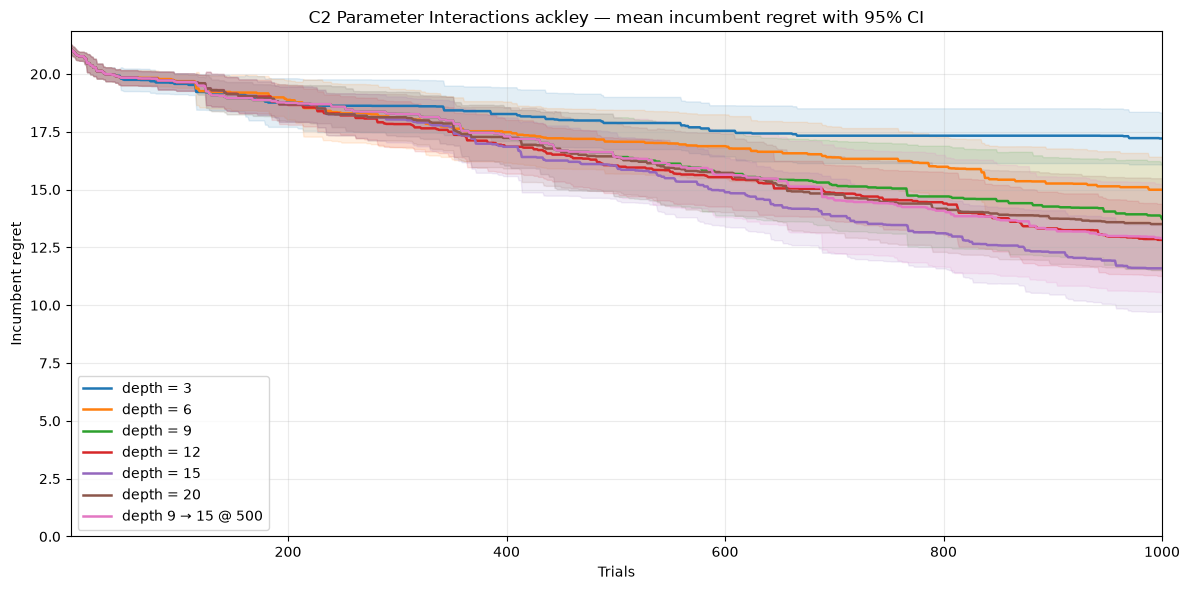

In [31]:
rows = [{"policy": policy, "seed": seed, "iteration": iteration, "best_regret": regret} for policy, runs in results.items() for seed, result in runs.items() for iteration, regret in zip(result["iteration"], result["best_regret"])]
trajectories = pd.DataFrame(rows)
summary = trajectories.groupby(["policy", "iteration"])["best_regret"].agg(["mean", "std", "count"]).reset_index()
summary["ci95"] = 1.96 * summary["std"] / np.sqrt(summary["count"])
fig, ax = plt.subplots(figsize=(12, 6))
for policy in POLICIES:
    data = summary[summary.policy == policy]
    ax.plot(data.iteration, data["mean"], label=LABELS[policy], color=COLORS[policy], linewidth=1.8)
    ax.fill_between(data.iteration, np.maximum(0, data["mean"] - data.ci95), data["mean"] + data.ci95, color=COLORS[policy], alpha=.12)
ax.set(title="C2 Parameter Interactions ackley — mean incumbent regret with 95% CI", xlabel="Trials", ylabel="Incumbent regret", xlim=(1, N_TRIALS), ylim=(0, None))
ax.grid(alpha=.25); ax.legend(); plt.tight_layout(); plt.show()

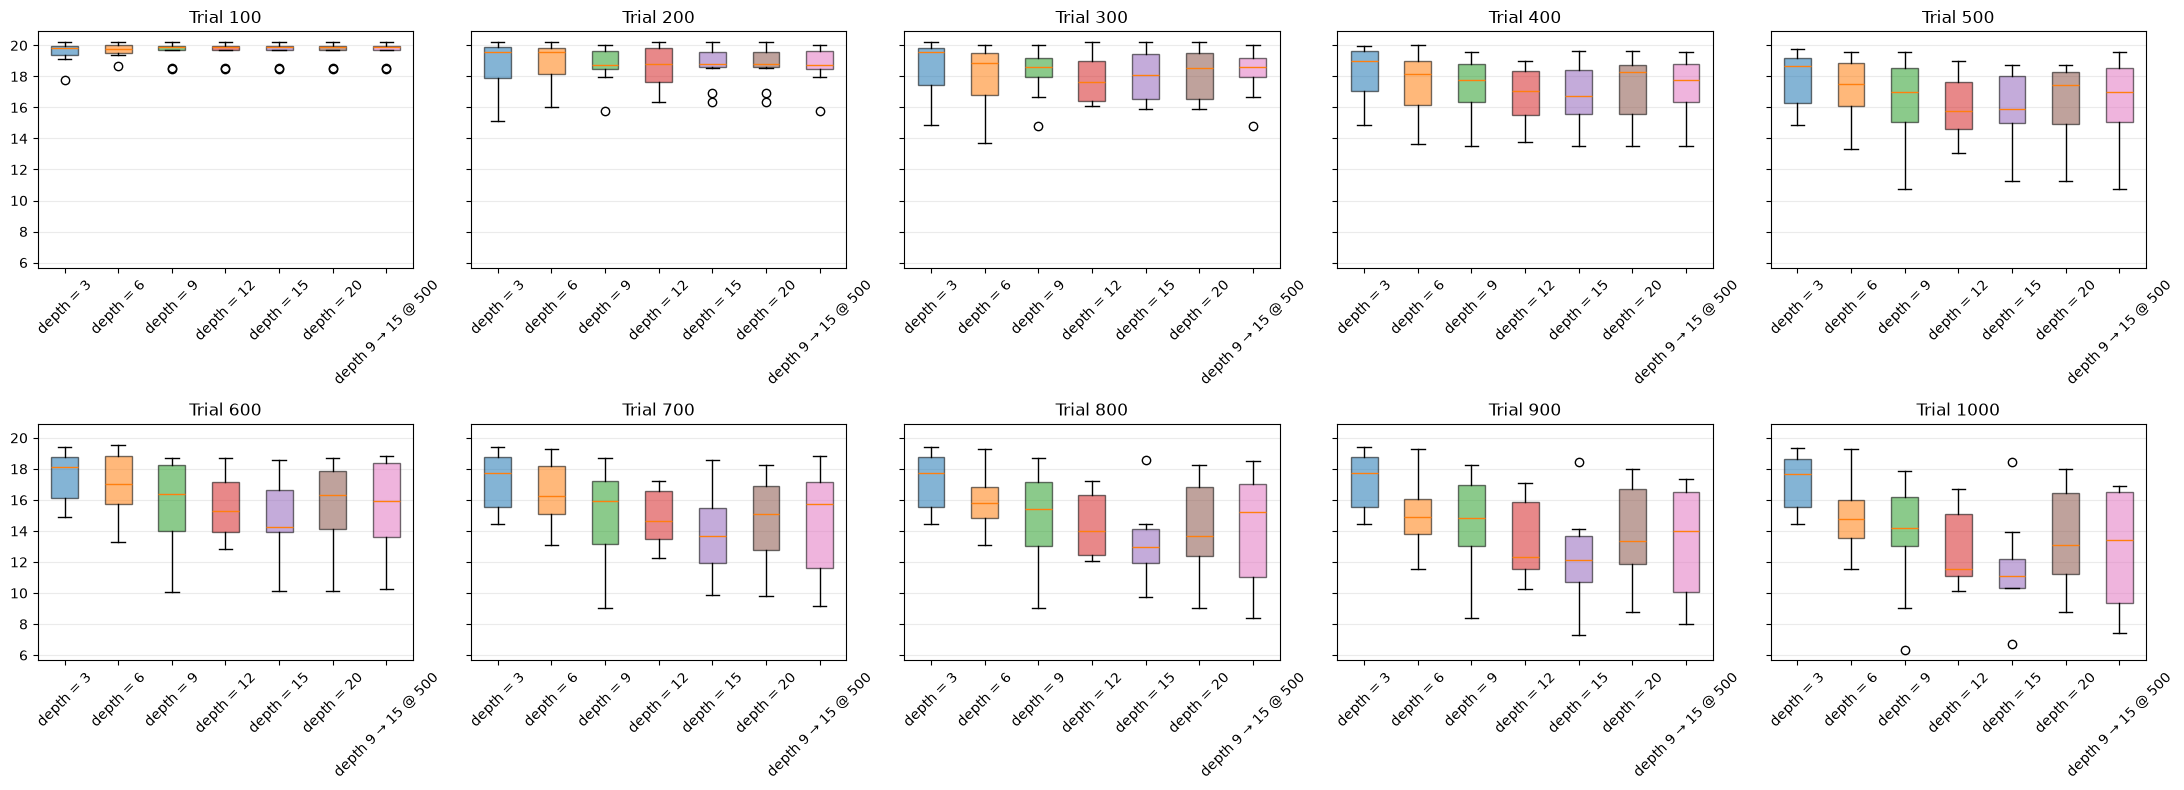

In [32]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8), sharey=True)
for ax, checkpoint in zip(axes.flat, CHECKPOINTS):
    values = [[results[policy][seed]["best_regret"][checkpoint - 1] for seed in SEEDS] for policy in POLICIES]
    boxes = ax.boxplot(values, patch_artist=True, tick_labels=[LABELS[policy] for policy in POLICIES])
    for box, policy in zip(boxes["boxes"], POLICIES): box.set(facecolor=COLORS[policy], alpha=.55)
    ax.set_title(f"Trial {checkpoint}"); ax.tick_params(axis="x", rotation=45); ax.grid(axis="y", alpha=.25)
plt.tight_layout(); plt.show()

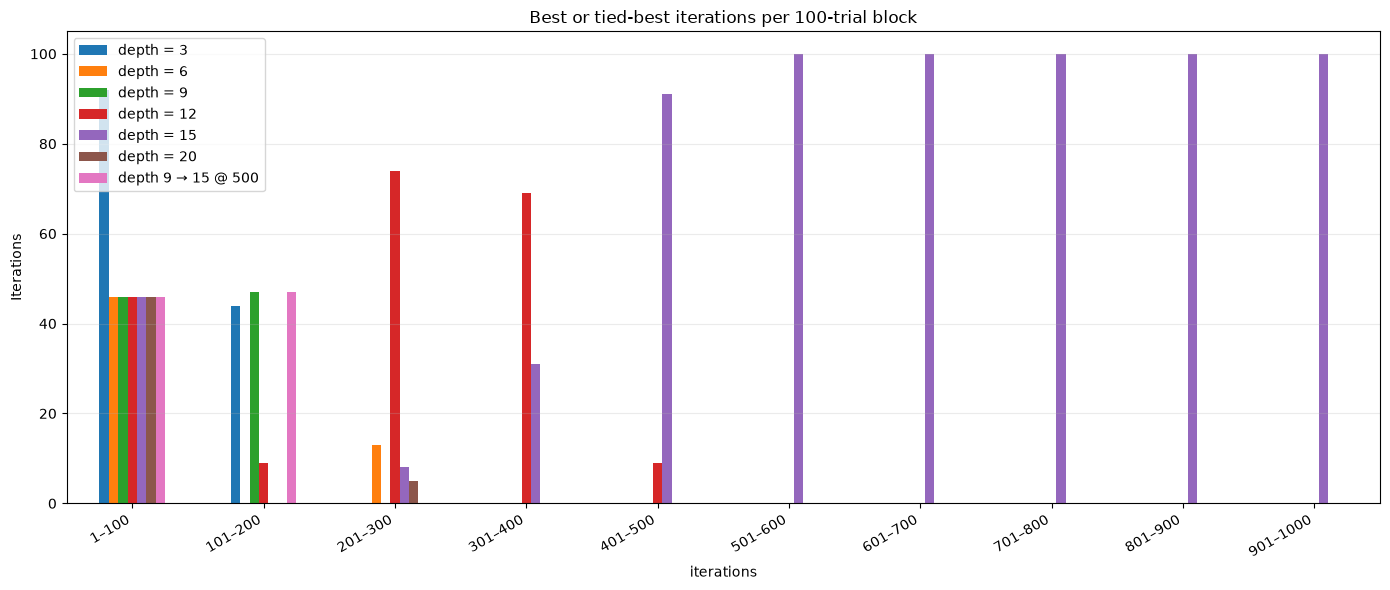

,iterations,superior policy,depth = 3,depth = 6,depth = 9,depth = 12,depth = 15,depth = 20,depth 9 → 15 @ 500
0,1–100,depth = 3,92,46,46,46,46,46,46
1,101–200,"depth = 9, depth 9 → 15 @ 500",44,0,47,9,0,0,47
2,201–300,depth = 12,0,13,0,74,8,5,0
3,301–400,depth = 12,0,0,0,69,31,0,0
4,401–500,depth = 15,0,0,0,9,91,0,0
5,501–600,depth = 15,0,0,0,0,100,0,0
6,601–700,depth = 15,0,0,0,0,100,0,0
7,701–800,depth = 15,0,0,0,0,100,0,0
8,801–900,depth = 15,0,0,0,0,100,0,0
9,901–1000,depth = 15,0,0,0,0,100,0,0


In [33]:
mean_regret = trajectories.pivot_table(index="iteration", columns="policy", values="best_regret", aggfunc="mean").reindex(columns=POLICIES)
best = mean_regret.min(axis=1)
wins = pd.DataFrame({policy: np.isclose(mean_regret[policy], best, rtol=1e-12, atol=1e-9) for policy in POLICIES}, index=mean_regret.index)
block_rows = []
for end in CHECKPOINTS:
    counts = wins.loc[end - 99:end].sum(); maximum = int(counts.max())
    row = {"iterations": f"{end - 99}–{end}", "superior policy": ", ".join(LABELS[policy] for policy in POLICIES if counts[policy] == maximum)}
    row.update({LABELS[policy]: int(counts[policy]) for policy in POLICIES}); block_rows.append(row)
block_superiority = pd.DataFrame(block_rows)
ax = block_superiority.set_index("iterations")[[LABELS[policy] for policy in POLICIES]].plot(kind="bar", figsize=(14, 6), color=[COLORS[policy] for policy in POLICIES])
ax.set(title="Best or tied-best iterations per 100-trial block", ylabel="Iterations", ylim=(0, 105)); ax.grid(axis="y", alpha=.25); plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", None): display(block_superiority)

In [34]:
run_rows = []
for policy, runs in results.items():
    for seed, result in runs.items():
        regret = np.asarray(result["best_regret"], dtype=float)
        run_rows.append({"policy": LABELS[policy], "seed": seed, "final_regret": regret[-1], "mean_incumbent_regret": regret.mean()})
run_metrics = pd.DataFrame(run_rows)
metric_summary = run_metrics.groupby("policy")[["final_regret", "mean_incumbent_regret"]].agg(["mean", "std", "median", "min", "max"]).sort_values(("final_regret", "mean"))
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", None):
    display(metric_summary)
    display(run_metrics.sort_values(["seed", "final_regret"]))

final_regret                                             \
                           mean       std     median        min        max   
policy                                                                       
depth = 15            11.595479  3.032580  11.075129   6.714439  18.465140   
depth = 12            12.824541  2.518860  11.536968  10.154052  16.690224   
depth 9 → 15 @ 500    12.901514  3.768334  13.403149   7.453699  16.916196   
depth = 20            13.507849  3.203284  13.107312   8.770979  17.967876   
depth = 9             13.737250  3.662102  14.197538   6.348030  17.874457   
depth = 6             14.993982  2.303883  14.742996  11.517159  19.269676   
depth = 3             17.210772  1.816493  17.640589  14.441259  19.359333   

                   mean_incumbent_regret                                  \
                                    mean       std     median        min   
policy                                                                     
depth = 15                     15.915547  1.714347  15.818875  12.881331   
depth = 12                     16.376449  1.587433  16.271169  14.635761   
depth 9 → 15 @ 500             16.481504  2.256672  17.125454  12.394255   
depth = 20                     16.518924  2.007105  16.775305  13.074673   
depth = 9                      16.744462  2.170492  17.271233  12.532808   
depth = 6                      17.322308  1.675869  17.509642  14.313846   
depth = 3                      18.141077  1.592244  18.842939  15.504594   

                               
                          max  
policy                         
depth = 15          18.886466  
depth = 12          18.180310  
depth 9 → 15 @ 500  18.999108  
depth = 20          18.759558  
depth = 9           19.094499  
depth = 6           19.628962  
depth = 3           19.551654

,policy,seed,final_regret,mean_incumbent_regret
67,depth 9 → 15 @ 500,0,8.292371,12.394255
27,depth = 9,0,9.025212,12.532808
57,depth = 20,0,10.153278,14.675237
47,depth = 15,0,11.000083,14.977849
37,depth = 12,0,11.003280,14.766581
17,depth = 6,0,13.117284,14.313846
7,depth = 3,0,14.868375,15.504594
66,depth 9 → 15 @ 500,1,7.453699,14.765748
36,depth = 12,1,10.154052,14.877093
56,depth = 20,1,11.824253,16.447632


In [35]:
checkpoint_table = trajectories[trajectories.iteration.isin(CHECKPOINTS)].groupby(["iteration", "policy"])["best_regret"].agg(["mean", "std", "min", "median", "max"])
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", None): display(checkpoint_table)

mean       std        min  \
iteration policy                                                        
100       fixed_depth_12               19.649205  0.611102  18.492043   
          fixed_depth_15               19.649205  0.611102  18.492043   
          fixed_depth_20               19.649205  0.611102  18.492043   
          fixed_depth_3                19.571169  0.718618  17.773633   
          fixed_depth_6                19.688611  0.464118  18.646631   
          fixed_depth_9                19.649205  0.611102  18.492043   
          staged_depth_9_15_after_500  19.649205  0.611102  18.492043   
200       fixed_depth_12               18.661467  1.381930  16.324569   
          fixed_depth_15               18.693293  1.237799  16.324569   
          fixed_depth_20               18.693293  1.237799  16.324569   
          fixed_depth_3                18.763498  1.695808  15.112998   
          fixed_depth_6                18.877822  1.371589  16.038640   
          fixed_depth_9                18.748725  1.264463  15.752536   
          staged_depth_9_15_after_500  18.748725  1.264463  15.752536   
300       fixed_depth_12               17.830624  1.598405  16.086463   
          fixed_depth_15               18.034794  1.604971  15.872046   
          fixed_depth_20               18.127824  1.624594  15.872046   
          fixed_depth_3                18.618137  1.838127  14.868375   
          fixed_depth_6                18.092387  2.032961  13.709051   
          fixed_depth_9                18.271599  1.545784  14.808789   
          staged_depth_9_15_after_500  18.271599  1.545784  14.808789   
400       fixed_depth_12               16.852265  1.874891  13.772248   
          fixed_depth_15               16.851368  2.045590  13.516092   
          fixed_depth_20               17.235559  2.133660  13.516092   
          fixed_depth_3                18.266407  1.872690  14.868375   
          fixed_depth_6                17.484474  2.129549  13.645840   
          fixed_depth_9                17.301955  2.037079  13.503489   
          staged_depth_9_15_after_500  17.301955  2.037079  13.503489   
500       fixed_depth_12               16.040215  1.934131  13.091145   
          fixed_depth_15               16.042695  2.314871  11.245109   
          fixed_depth_20               16.436767  2.416030  11.245109   
          fixed_depth_3                17.879997  1.819166  14.868375   
          fixed_depth_6                17.069327  2.221925  13.331681   
          fixed_depth_9                16.417168  2.752368  10.747725   
          staged_depth_9_15_after_500  16.417168  2.752368  10.747725   
600       fixed_depth_12               15.539155  2.049840  12.857138   
          fixed_depth_15               14.885200  2.419262  10.124094   
          fixed_depth_20               15.723568  2.738963  10.124094   
          fixed_depth_3                17.541628  1.784656  14.868375   
          fixed_depth_6                16.877591  2.226288  13.295811   
          fixed_depth_9                15.705851  2.948599  10.049146   
          staged_depth_9_15_after_500  15.646714  2.955011  10.246168   
700       fixed_depth_12               14.862440  1.941390  12.285031   
          fixed_depth_15               13.852960  2.608215   9.842444   
          fixed_depth_20               14.805002  2.682644   9.822010   
          fixed_depth_3                17.330525  1.912392  14.441259   
          fixed_depth_6                16.392314  2.156871  13.117284   
          fixed_depth_9                15.196362  3.106842   9.025212   
          staged_depth_9_15_after_500  14.554217  3.697205   9.136169   
800       fixed_depth_12               14.395516  2.179133  12.082367   
          fixed_depth_15               13.110406  2.453170   9.772767   
          fixed_depth_20               14.171095  3.008966   9.055901   
          fixed_depth_3                17.330525  1.912392  14.441259   
          fixed_depth_6      